In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm #imports

In [59]:
df = pd.read_csv('taylor_album_songs.csv') #pega o csv

features = ['energy', 'danceability'] #so duas pra deixar 2d e mais simples
df = df[features + ['album_name']].dropna() #limpa campos vazios se tiver 

In [60]:
X = df[features].values #dados
y = df['album_name'].astype('category').cat.codes.values #joga os nomes de albuns pra nmers
album_labels = df['album_name'].astype('category').cat.categories #salva os nomes e dps volta pra gente ler melhor

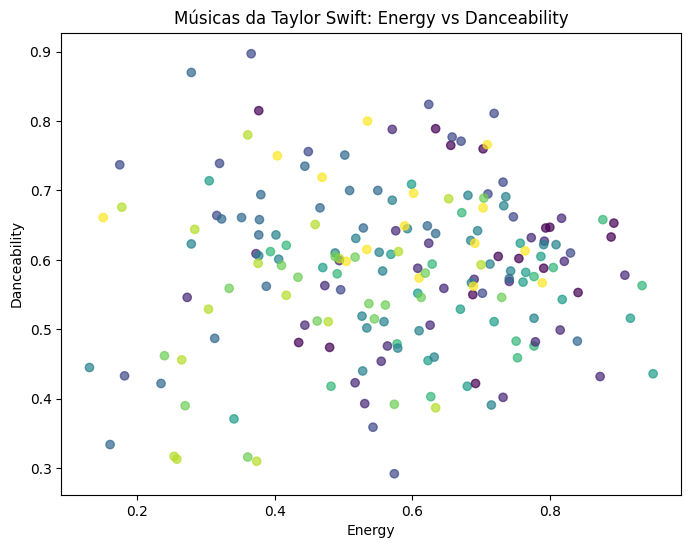

In [61]:
plt.figure(figsize = (8, 6)) #tamanho do grafico 
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'viridis', alpha = 0.7) #pega os pontos 
plt.title('Músicas da Taylor Swift: Energy vs Danceability')
plt.xlabel('Energy')
plt.ylabel('Danceability') #monta o grafico
plt.show()

In [62]:
scaling = MinMaxScaler(feature_range=(-1, 1)).fit(X) #coloca tudo na msm escala
X_scaled = scaling.transform(X) #aplica a escala

In [63]:
svc = svm.SVC(kernel = 'linear', C = 1.0).fit(X_scaled, y) #treina e linear faz a linha reta e nao curva

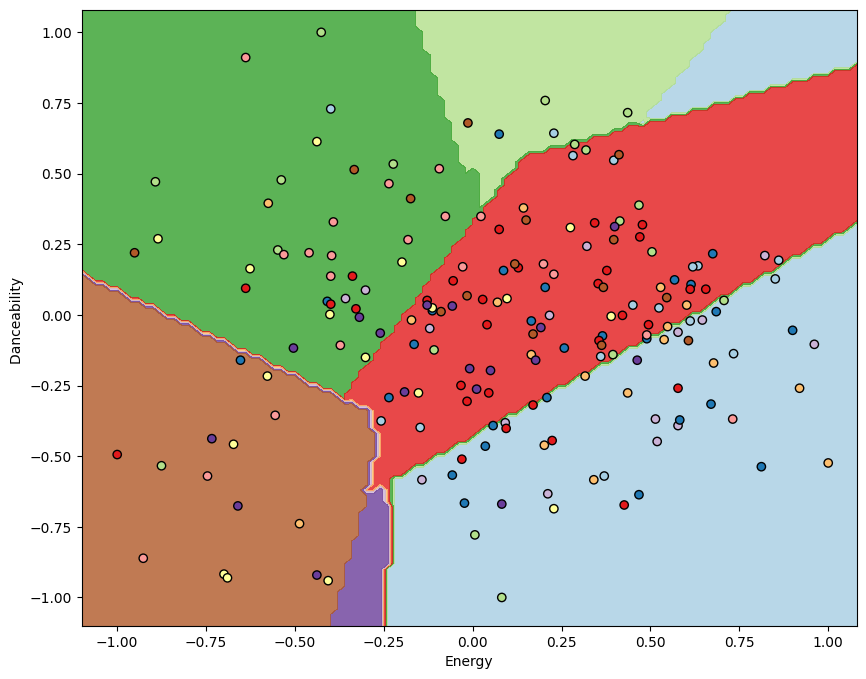

In [68]:
def predictMusc(clf, X_data, y_data): #funcao
    xx, yy = np.meshgrid(np.arange(-1.1, 1.1, 0.02),
                         np.arange(-1.1, 1.1, 0.02)) #grade de ponto que e caad msc
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]) #modelo preve pro grafico
    Z = Z.reshape(xx.shape) #resheipa pra grid

    plt.figure(figsize = (10, 8)) #tamanho da fig
    plt.contourf(xx, yy, Z, cmap = plt.cm.Paired, alpha = 0.8) #desenha as regioes
    plt.scatter(X_data[:, 0], X_data[:, 1], c = y_data, edgecolors = 'k', cmap = plt.cm.Paired)
    plt.xlabel('Energy')
    plt.ylabel('Danceability ') 
    plt.show()

predictMusc(svc, X_scaled, y)

In [67]:
teste = [[0.8, 0.7]] #faz uma musica fake
predicao_num = svc.predict(scaling.transform(teste))
print(album_labels[predicao_num[0]]) #e ve como ele previu a msc

Red (Taylor's Version)
